In [2]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [10]:
IMAGE_SHAPE = (224, 224)

# Load pre-trained MobileNetV2 from keras applications
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SHAPE + (3,),
    include_top=True,
    weights='imagenet'
)
base_model.trainable = False

classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=IMAGE_SHAPE + (3,)),
    tf.keras.layers.Rescaling(1./127.5, offset=-1),
    base_model
])

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


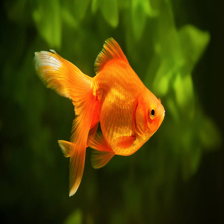

In [13]:
gold_fish = Image.open("images/gold-fish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [14]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [15]:
gold_fish

array([[[0.01176471, 0.03529412, 0.        ],
        [0.01960784, 0.04313725, 0.        ],
        [0.02352941, 0.04705882, 0.        ],
        ...,
        [0.07058824, 0.08235294, 0.        ],
        [0.07058824, 0.08235294, 0.        ],
        [0.07058824, 0.08235294, 0.        ]],

       [[0.01176471, 0.03529412, 0.        ],
        [0.01960784, 0.04313725, 0.        ],
        [0.02745098, 0.04705882, 0.        ],
        ...,
        [0.07058824, 0.08235294, 0.        ],
        [0.07058824, 0.08235294, 0.        ],
        [0.07058824, 0.08235294, 0.        ]],

       [[0.01176471, 0.03529412, 0.        ],
        [0.01960784, 0.04313725, 0.        ],
        [0.02745098, 0.05098039, 0.00392157],
        ...,
        [0.07058824, 0.08235294, 0.        ],
        [0.07058824, 0.08235294, 0.        ],
        [0.07058824, 0.08235294, 0.        ]],

       ...,

       [[0.01176471, 0.01176471, 0.00392157],
        [0.01176471, 0.01176471, 0.00392157],
        [0.01176471, 0

In [16]:
gold_fish[np.newaxis, ...].shape

(1, 224, 224, 3)

In [18]:
result = classifier.predict(gold_fish[np.newaxis, ...])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


(1, 1000)

In [19]:
predicted_label_index = np.argmax(result)
predicted_label_index

np.int64(818)

In [20]:
image_labels = []
with open("data/ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
    
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [21]:
image_labels[predicted_label_index]

'sports car'

In [22]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='.', untar=True)

In [23]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [25]:
list(data_dir.rglob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [27]:
image_count = len(list(data_dir.rglob('*/*.jpg')))
print(image_count)

3670


In [29]:
roses = list(data_dir.rglob("roses/*"))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

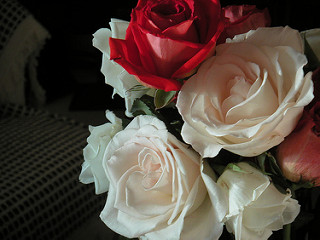

In [30]:
Image.open(str(roses[1]))

In [31]:
flowers_images_dict = {
    'roses': list(data_dir.rglob('roses/*')),
    'daisy': list(data_dir.rglob('daisy/*')),
    'dandelion': list(data_dir.rglob('dandelion/*')),
    'sunflower': list(data_dir.rglob('sunflowers/*')),
    'tulips': list(data_dir.rglob('tulips/*'))
}

In [32]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflower': 3,
    'tulips': 4
}

In [33]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [34]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(240, 179, 3)

In [35]:
cv2.resize(img, IMAGE_SHAPE).shape

(224, 224, 3)

In [36]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    print(flower_name)
    print(len(images))
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, IMAGE_SHAPE)
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

roses
641
daisy
633
dandelion
898
sunflower
699
tulips
799


In [37]:
X = np.array(X)
y = np.array(y)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [39]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

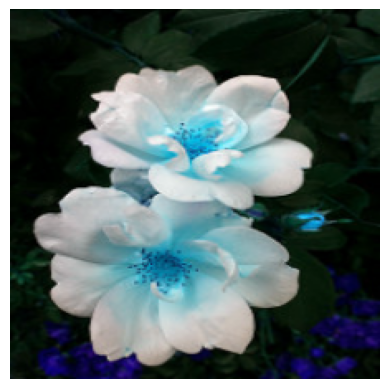

In [40]:
plt.axis('off')
plt.imshow(X[0])

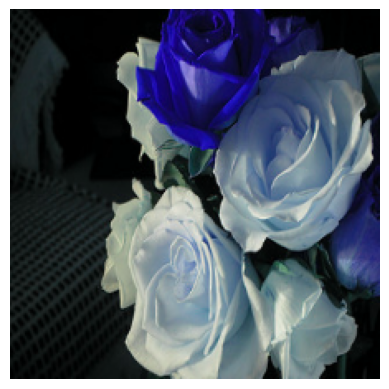

In [41]:
plt.axis('off')
plt.imshow(X[1])

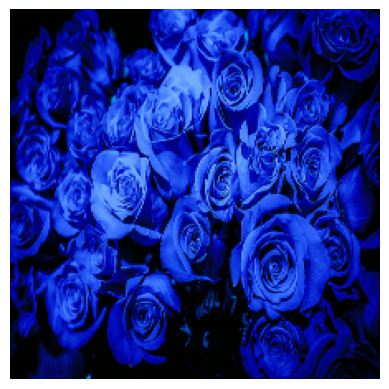

In [42]:
plt.axis('off')
plt.imshow(X[2])

In [47]:
predicted =classifier.predict(np.array([X[0], X[1], X[2]]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


array([584, 459, 885])

In [48]:
image_labels[584]

'guillotine'

In [50]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"
pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False
)

In [53]:
num_of_flowers = 5

# Use base_model from earlier (MobileNetV2) as the feature extractor
inputs = tf.keras.Input(shape=IMAGE_SHAPE + (3,))
x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(inputs)
x = base_model(x)
outputs = tf.keras.layers.Dense(num_of_flowers)(x)
model = tf.keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1000)           │     3,538,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,543,989 (13.52 MB)

 Trainable params: 5,005 (19.55 KB)

 Non-trainable params: 3,538,984 (13.50 MB)

In [54]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc']
)

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 47s 486ms/step - acc: 0.2442 - loss: 1.6058
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 51s 595ms/step - acc: 0.2442 - loss: 1.6021
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 54s 622ms/step - acc: 0.2442 - loss: 1.6010
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 53s 618ms/step - acc: 0.2442 - loss: 1.6004
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 38s 443ms/step - acc: 0.2442 - loss: 1.6003
